# 1. Data cleaning
#### A. Load and examine data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("creditcard.csv")

# Clean column names just in case there are whitespaces
data.columns = data.columns.str.strip()

data.head()
data.info()
data.describe()

# The above lines of code enable us to understand the shape, column types,
# and general distribution of the dataset.

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


#### B. Check missing values

In [4]:
missing_values = data.isnull().sum()
missing_values[missing_values > 0]

Series([], dtype: int64)

#### C. Check duplicate rows

In [5]:
duplicate_count = data.duplicated().sum()
duplicate_count

data_cleaned = data.drop_duplicates()
data_cleaned.shape

(283726, 31)

## 3. Handle outliers and noise cautiously

True


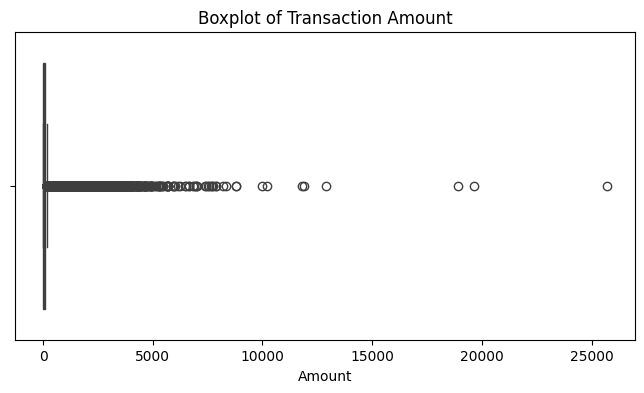

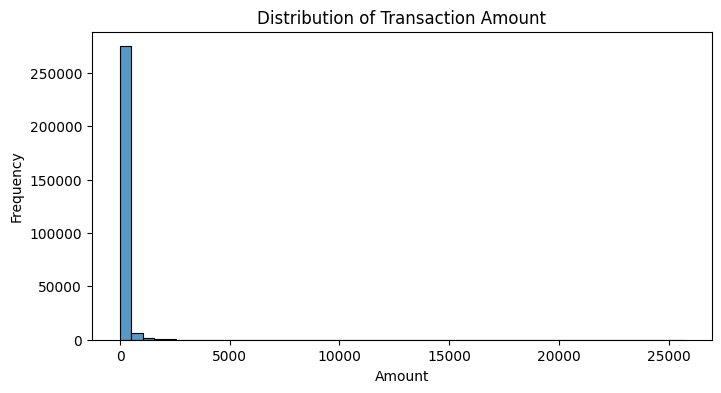

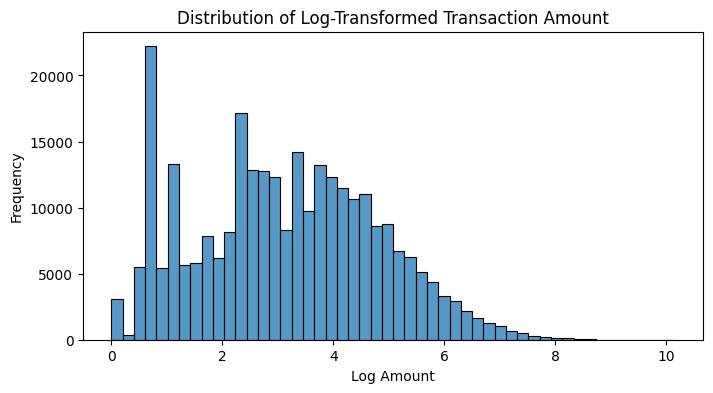

In [6]:
# Check if Amount column exists
print("Amount" in data_cleaned.columns)

# Boxplot of transaction amount
plt.figure(figsize=(8, 4))
sns.boxplot(x=data_cleaned["Amount"])
plt.title("Boxplot of Transaction Amount")
plt.xlabel("Amount")
plt.show()

# Histogram of transaction amount
plt.figure(figsize=(8, 4))
sns.histplot(data_cleaned["Amount"], bins=50)
plt.title("Distribution of Transaction Amount")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

# Log transformation of Amount
data_cleaned["Log_Amount"] = np.log1p(data_cleaned["Amount"])

# Histogram of log-transformed amount
plt.figure(figsize=(8, 4))
sns.histplot(data_cleaned["Log_Amount"], bins=50)
plt.title("Distribution of Log-Transformed Transaction Amount")
plt.xlabel("Log Amount")
plt.ylabel("Frequency")
plt.show()

## 3. Class imbalance EDA

In [7]:
# Check if Class column exists
print("Class" in data_cleaned.columns)

# Count class values
class_counts = data_cleaned["Class"].value_counts()
class_percentages = data_cleaned["Class"].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)
print("\nClass Percentages:")
print(class_percentages)

True
Class Counts:
Class
0    283253
1       473
Name: count, dtype: int64

Class Percentages:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


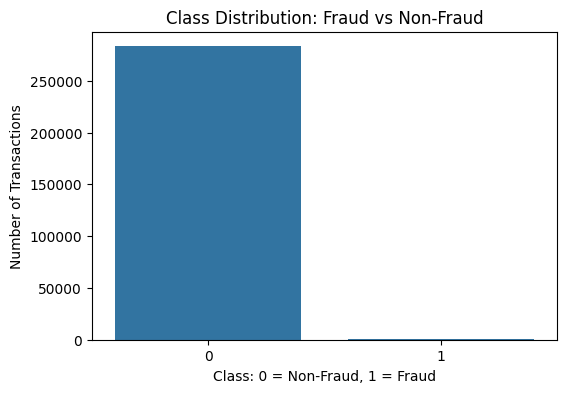

In [28]:
# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="Class", data=data_cleaned)
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class: 0 = Non-Fraud, 1 = Fraud")
plt.ylabel("Number of Transactions")
plt.show()

## 4. Compare fraud and non-fraud transaction amounts

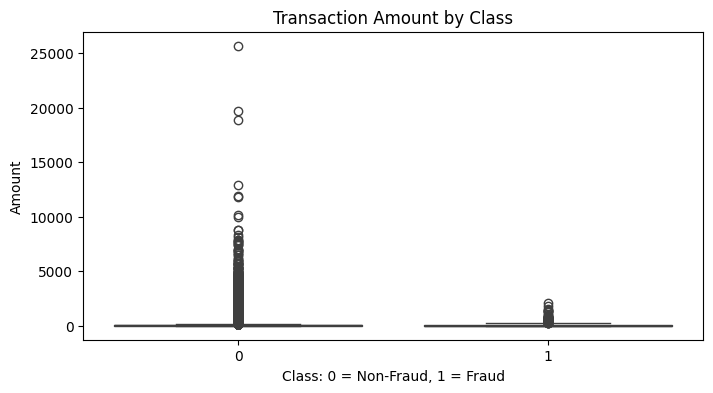

count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

In [23]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Class", y="Amount", data=data_cleaned)
plt.title("Transaction Amount by Class")
plt.xlabel("Class: 0 = Non-Fraud, 1 = Fraud")
plt.ylabel("Amount")
plt.show()
data_cleaned["Amount"].describe()

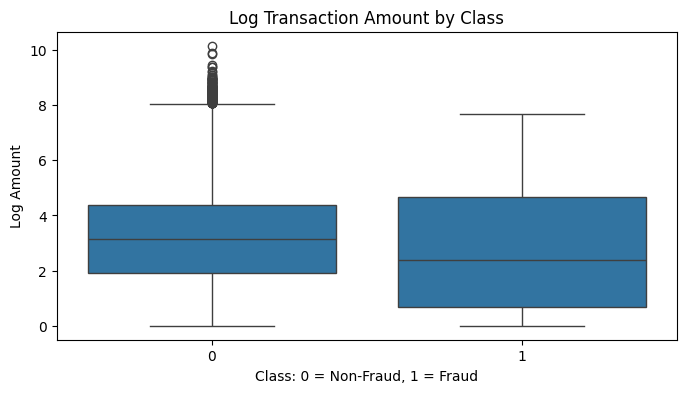

In [11]:
plt.figure(figsize=(8, 4))
sns.boxplot(x="Class", y="Log_Amount", data=data_cleaned)
plt.title("Log Transaction Amount by Class")
plt.xlabel("Class: 0 = Non-Fraud, 1 = Fraud")
plt.ylabel("Log Amount")
plt.show()

## 5. Time-based EDA

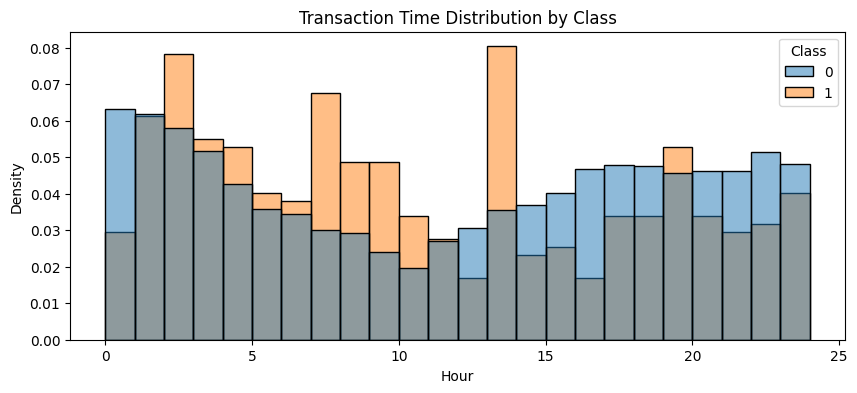

In [12]:
# Convert the Time column to hours to make it easier to understand
data_cleaned["Hour"] = (data_cleaned["Time"] / 3000) % 24

plt.figure(figsize=(10, 4))
sns.histplot(data=data_cleaned, x="Hour", hue="Class", bins=24, stat="density", common_norm=False)
plt.title("Transaction Time Distribution by Class")
plt.xlabel("Hour")
plt.ylabel("Density")
plt.show()

## 6. Feature selection / feature importance for EDA

In [13]:
feature_cols = [col for col in data_cleaned.columns if col.startswith("V")]

mean_by_class = data_cleaned.groupby("Class")[feature_cols].mean().T
mean_by_class["difference"] = abs(mean_by_class[1] - mean_by_class[0])
mean_by_class = mean_by_class.sort_values("difference", ascending=False)

mean_by_class.head(10)

Class,0,1,difference
V14,0.011668,-6.835946,6.847614
V3,0.012853,-6.729599,6.742452
V17,0.010963,-6.463285,6.474249
V12,0.009476,-6.103254,6.112730
V10,0.007663,-5.453274,5.460937
V7,0.010447,-5.175912,5.186359
V1,0.013439,-4.498280,4.511719
V4,-0.010440,4.472591,4.483031
V16,0.007845,-4.000956,4.008801
V11,-0.006004,3.716347,3.722350


##### Plot top features:

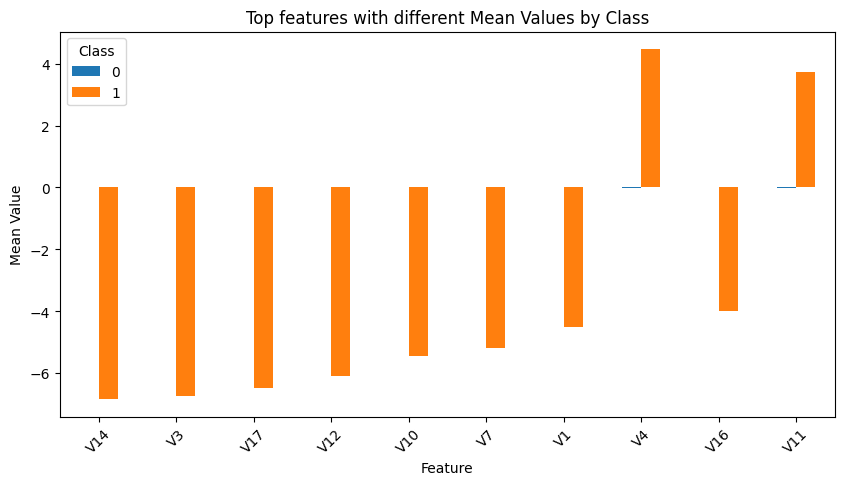

In [14]:
top_features = mean_by_class.head(10).index

mean_by_class.loc[top_features, [0, 1]].plot(kind="bar", figsize=(10, 5))
plt.title("Top features with different Mean Values by Class")
plt.xlabel("Feature")
plt.ylabel("Mean Value")
plt.xticks(rotation=45)
plt.show()

## 7. Feature scaling / transformation

In [26]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

data_cleaned["Scaled_Amount"] = scaler.fit_transform(data_cleaned[["Amount"]])
data_cleaned["Scaled_Time"] = scaler.fit_transform(data_cleaned[["Time"]])
data_model = data_cleaned.drop(["Amount", "Time"], axis=1)